In [77]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [78]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [79]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [80]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [81]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [82]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

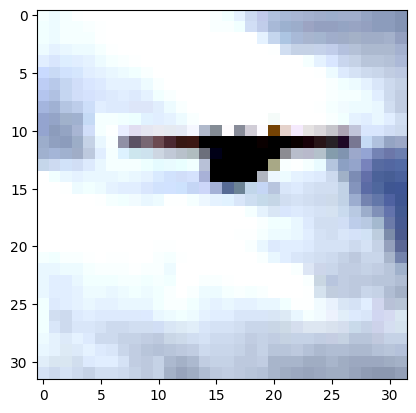

In [83]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [84]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [85]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [86]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [87]:
class Trainer:
    def __init__(self, config, model, transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = model().to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.train_losses = []
        self.train_accs = []
        self.val_losses = []
        self.val_accs = []
        self.test_loss = None
        self.test_acc = None

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)
            self.val_losses.append(val_loss)
            self.val_accs.append(val_acc)

            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}',
                  f'    Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%',
                  f'    Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%', sep='\n')

        test_loss, test_acc = self.test_step()
        self.test_loss = test_loss
        self.test_acc = test_acc
        print(f'Test loss {test_loss}, test acc {test_acc}')

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [88]:
trainer_cnn = Trainer(config, model=BasicCNN, transform=transform)

In [89]:
trainer_cnn.run()

100%|██████████| 79/79 [00:02<00:00, 31.76it/s]


Epoch 1 / 10
    Train Loss: 1.5998, Train Acc: 40.99%
    Val Loss: 1.4236, Val Acc: 48.31%


100%|██████████| 79/79 [00:02<00:00, 32.42it/s]


Epoch 2 / 10
    Train Loss: 1.3146, Train Acc: 52.68%
    Val Loss: 1.3154, Val Acc: 53.57%


100%|██████████| 79/79 [00:02<00:00, 31.58it/s]


...

Epoch 9 / 10
    Train Loss: 0.8155, Train Acc: 70.92%
    Val Loss: 1.0557, Val Acc: 63.89%


100%|██████████| 79/79 [00:02<00:00, 32.07it/s]


Epoch 10 / 10
    Train Loss: 0.7938, Train Acc: 71.74%
    Val Loss: 1.0521, Val Acc: 64.26%


100%|██████████| 79/79 [00:02<00:00, 32.16it/s]

Test loss 1.0463485317894174, test acc 64.27000000000001


# ResNet-18

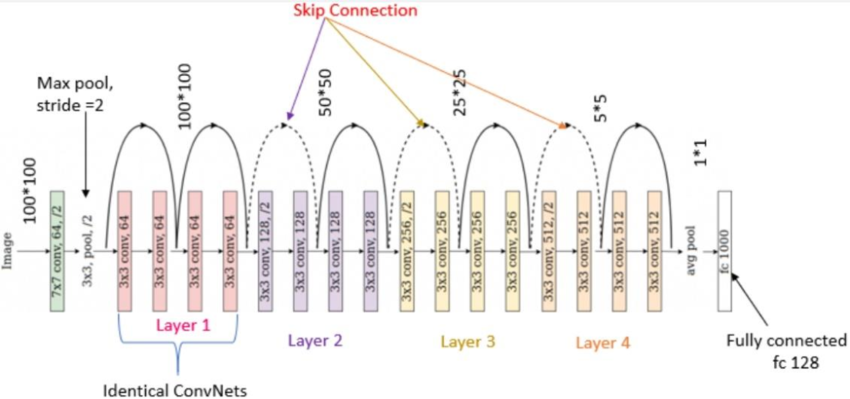

In [90]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        # первый сверточный слой блока
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # второй сверточный слой блока
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        # Применить свертки + skip connection
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = F.relu(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        # начальный сверточный слой, как в классическом ResNet-18
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Сделать 4 блока
        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None

        # если меняется размер карты признаков или stride, подгоняем skip-путь
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResNetBlock(self.in_channels, out_channels, stride=stride, downsample=downsample))
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResNetBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # начальный блок
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.max_pool(x)

        # основные residual-блоки
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # усреднение и классификатор
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [91]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN
trainer_resnet = Trainer(config, model=ResNet18, transform=transform)

In [92]:
trainer_resnet.run()

100%|██████████| 79/79 [00:03<00:00, 26.25it/s]


Epoch 1 / 10
    Train Loss: 1.8251, Train Acc: 35.65%
    Val Loss: 1.5033, Val Acc: 44.52%


100%|██████████| 79/79 [00:03<00:00, 24.35it/s]


Epoch 2 / 10
    Train Loss: 1.3378, Train Acc: 51.17%
    Val Loss: 1.2354, Val Acc: 56.10%


100%|██████████| 79/79 [00:03<00:00, 21.90it/s]


...

Epoch 9 / 10
    Train Loss: 0.2599, Train Acc: 91.26%
    Val Loss: 0.8754, Val Acc: 74.92%


100%|██████████| 79/79 [00:03<00:00, 26.26it/s]


Epoch 10 / 10
    Train Loss: 0.1812, Train Acc: 94.01%
    Val Loss: 1.0009, Val Acc: 74.68%


100%|██████████| 79/79 [00:04<00:00, 19.74it/s]

Test loss 0.998697553254381, test acc 74.68


------------------------------------------------------------
FINAL RESULTS
------------------------------------------------------------
BasicCNN - Test Accuracy: 64.27%, Test Loss: 1.0463
ResNet-18 - Test Accuracy: 74.68%, Test Loss: 0.9987
Difference in accuracy: +10.41%


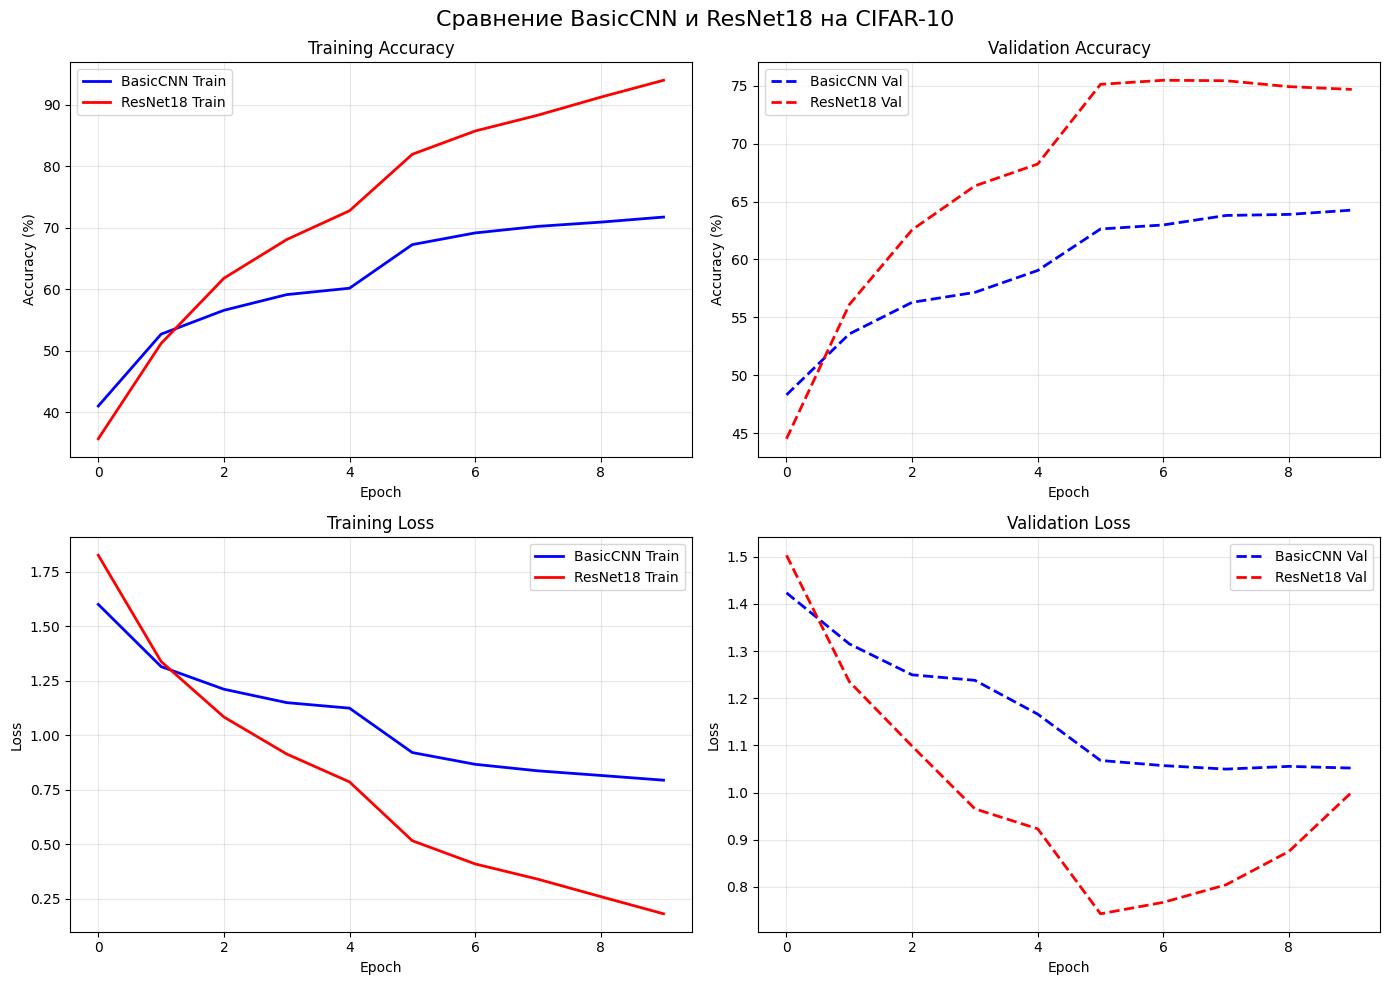

In [93]:
# Сравнение динамики обучения BasicCNN и ResNet18

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение BasicCNN и ResNet18 на CIFAR-10', fontsize=16)

# Accuracy на train
axes[0, 0].plot(trainer_cnn.train_accs, 'b-', label='BasicCNN Train', linewidth=2)
axes[0, 0].plot(trainer_resnet.train_accs, 'r-', label='ResNet18 Train', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Training Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy на val
axes[0, 1].plot(trainer_cnn.val_accs, 'b--', label='BasicCNN Val', linewidth=2)
axes[0, 1].plot(trainer_resnet.val_accs, 'r--', label='ResNet18 Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Loss на train
axes[1, 0].plot(trainer_cnn.train_losses, 'b-', label='BasicCNN Train', linewidth=2)
axes[1, 0].plot(trainer_resnet.train_losses, 'r-', label='ResNet18 Train', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss на val
axes[1, 1].plot(trainer_cnn.val_losses, 'b--', label='BasicCNN Val', linewidth=2)
axes[1, 1].plot(trainer_resnet.val_losses, 'r--', label='ResNet18 Val', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Validation Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

print('-' * 60)
print('FINAL RESULTS')
print('-' * 60)
print(f"BasicCNN - Test Accuracy: {trainer_cnn.test_acc:.2f}%, Test Loss: {trainer_cnn.test_loss:.4f}")
print(f"ResNet-18 - Test Accuracy: {trainer_resnet.test_acc:.2f}%, Test Loss: {trainer_resnet.test_loss:.4f}")
print(f"Difference in accuracy: {trainer_resnet.test_acc - trainer_cnn.test_acc:+.2f}%")

plt.tight_layout()
plt.show()